# PHASE 2 : DATA CLEANING & PREPROCESSING

## Data Cleaning & Preprocessing

In this phase, we transform raw scraped data into a clean, structured dataset suitable for analysis and machine learning.

Key steps:
- Handling missing values
- Removing duplicates
- Fixing data types
- Feature engineering
- Preparing data for EDA & modeling

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("books_with_category.csv")

df.head()

C:\Users\RAM\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\RAM\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


,Title,Price,Rating,Availability,Product_URL,Category
0,A Light in the Attic,51.77,3,In stock,http://books.toscrape.com/catalogue/a-light-in...,Poetry
1,Tipping the Velvet,53.74,1,In stock,http://books.toscrape.com/catalogue/tipping-th...,Historical Fiction
2,Soumission,50.10,1,In stock,http://books.toscrape.com/catalogue/soumission...,Fiction
3,Sharp Objects,47.82,4,In stock,http://books.toscrape.com/catalogue/sharp-obje...,Mystery
4,Sapiens: A Brief History of Humankind,54.23,5,In stock,http://books.toscrape.com/catalogue/sapiens-a-...,History


In [2]:
#pd.set_option('display.max_rows', None)
#df

### Initial Data Inspection

We first explore the dataset structure, data types, and basic statistics to understand data quality.

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (1000, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         1000 non-null   str    
 1   Price         1000 non-null   float64
 2   Rating        1000 non-null   int64  
 3   Availability  1000 non-null   str    
 4   Product_URL   1000 non-null   str    
 5   Category      1000 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 188.4 KB


,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


### Handling Missing Values

We check for missing values in each column and decide appropriate treatment strategies.

In [4]:
df.isnull().sum()

Title           0
Price           0
Rating          0
Availability    0
Product_URL     0
Category        0
dtype: int64

If missing values exist:
- Numerical → fill with mean/median
- Categorical → fill with mode or "Unknown"

The dataset was relatively clean with no missing values after scraping.

In [5]:
# (if needed)
# df["Rating"].fillna(df["Rating"].median(), inplace=True)
# df["Category"].fillna("Unknown", inplace=True)

### Removing Duplicates

Duplicate records can distort analysis, so we remove them.

In [6]:
print("Before:", df.shape)

df.drop_duplicates(inplace=True)

print("After:", df.shape)

Before: (1000, 6)
After: (1000, 6)


No duplicate records were found, ensuring data integrity.

### Fixing Data Types

Ensuring all columns are in correct formats for analysis.

In [7]:
df.dtypes

Title               str
Price           float64
Rating            int64
Availability        str
Product_URL         str
Category            str
dtype: object

### Fixing inconsistency 

Category = “Default”
That’s not a real category
We will replace it with "Unknown" 

In [8]:
print(df["Category"].value_counts())

Category
Default               152
Nonfiction            110
Sequential Art         75
Add a comment          67
Fiction                65
Young Adult            54
Fantasy                48
Romance                35
Mystery                32
Food and Drink         30
Childrens              29
Historical Fiction     26
Poetry                 19
Classics               19
History                18
Horror                 17
Womens Fiction         17
Science Fiction        16
Science                14
Music                  13
Business               12
Travel                 11
Thriller               11
Philosophy             11
Humor                  10
Autobiography           9
Art                     8
Religion                7
Psychology              7
Spirituality            6
New Adult               6
Christian Fiction       6
Self Help               5
Biography               5
Sports and Games        5
Health                  4
Politics                3
Contemporary            3
Chr

In [9]:
df["Category"] = df["Category"].replace("Default", "Unknown")

## Feature Engineering

In this step, we create new meaningful features from existing data to enhance analysis and improve model performance.

These features help uncover hidden patterns and make the dataset more informative.

In [10]:
df['Availability'].value_counts()

Availability
In stock    1000
Name: count, dtype: int64

Since all values are same we will drop the Availability column.

In [11]:
df.drop("Availability", axis=1, inplace=True)

### Creating Price Bands

We categorize prices into Low, Medium, and High to analyze pricing behavior.

In [12]:
def price_band(price):
    if price < 20:
        return "Low"
    elif price < 40:
        return "Medium"
    else:
        return "High"

df["Price_Band"] = df["Price"].apply(price_band)

### Rating Category

We group ratings into categories to simplify analysis.

In [13]:
def rating_category(rating):
    if rating >= 4:
        return "Good"
    elif rating >= 2:
        return "Average"
    else:
        return "Poor"

df["Rating_Category"] = df["Rating"].apply(rating_category)

### Review Intensity (Proxy Feature)

Since we don't have actual review counts, we simulate a proxy based on rating.

In [14]:
df["Rating_Score"] = df["Rating"] / 5

### Title Length Feature

We analyze how product title length impacts ratings.

In [15]:
df["Title_Length"] = df["Title"].apply(len)

## Feature Engineering Completed

The dataset now includes additional features that improve analytical depth and model performance.

In [17]:
#pd.set_option('display.max_rows', None)
#df

In [18]:
df.head()

,Title,Price,Rating,Product_URL,Category,Price_Band,Rating_Category,Rating_Score,Title_Length
0,A Light in the Attic,51.77,3,http://books.toscrape.com/catalogue/a-light-in...,Poetry,High,Average,0.6,20
1,Tipping the Velvet,53.74,1,http://books.toscrape.com/catalogue/tipping-th...,Historical Fiction,High,Poor,0.2,18
2,Soumission,50.10,1,http://books.toscrape.com/catalogue/soumission...,Fiction,High,Poor,0.2,10
3,Sharp Objects,47.82,4,http://books.toscrape.com/catalogue/sharp-obje...,Mystery,High,Good,0.8,13
4,Sapiens: A Brief History of Humankind,54.23,5,http://books.toscrape.com/catalogue/sapiens-a-...,History,High,Good,1.0,37


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Title            1000 non-null   str    
 1   Price            1000 non-null   float64
 2   Rating           1000 non-null   int64  
 3   Product_URL      1000 non-null   str    
 4   Category         1000 non-null   str    
 5   Price_Band       1000 non-null   str    
 6   Rating_Category  1000 non-null   str    
 7   Rating_Score     1000 non-null   float64
 8   Title_Length     1000 non-null   int64  
dtypes: float64(2), int64(2), str(5)
memory usage: 213.6 KB


# PHASE 3 : EXPLORATORY DATA ANALYSIS (EDA)

## Exploratory Data Analysis (EDA)

In this phase, we analyze the dataset to uncover patterns, trends, and relationships between variables.

Goal:
- Understand pricing and rating behavior
- Identify top-performing categories
- Discover key factors affecting ratings

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

### Summary Statistics

We begin by analyzing basic statistical measures of numerical features.

In [23]:
df[["Price", "Rating"]].describe()

,Price,Rating
count,1000.00000,1000.000000
mean,35.07035,2.923000
std,14.44669,1.434967
min,10.00000,1.000000
25%,22.10750,2.000000
50%,35.98000,3.000000
75%,47.45750,4.000000
max,59.99000,5.000000


- Average price is around **35**, with a wide range from **10 to 60**, indicating varied pricing.
- Average rating is **2.9**, slightly below 3, showing overall moderate to low ratings.
- Most ratings fall between **2 and 4**, indicating books are generally average to good.

### Distribution of Ratings

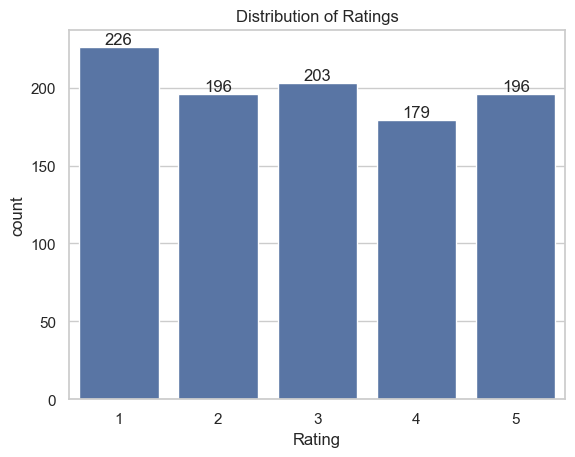

In [24]:
ax = sns.countplot(x="Rating", data=df)

ax.bar_label(ax.containers[0])

plt.title("Distribution of Ratings")
plt.show()

- Rating **1 has the highest count**, indicating many low-rated books.
- Ratings are **fairly evenly distributed** across all levels.
- Slight skew toward lower ratings suggests **inconsistent product quality**.

### Price Distribution

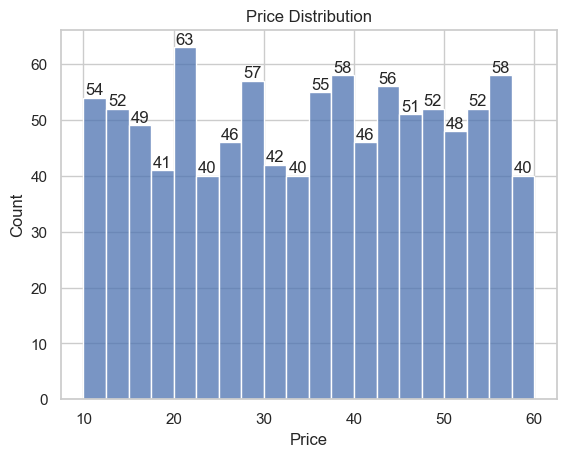

In [25]:
ax=sns.histplot(df["Price"], bins=20)

ax.bar_label(ax.containers[0])

plt.title("Price Distribution")
plt.show()

- Prices are evenly distributed between 10 and 60.
- No strong concentration in any specific price range.

Interpretation:
- The dataset shows balanced pricing with no price bias.

### Category-wise Average Rating

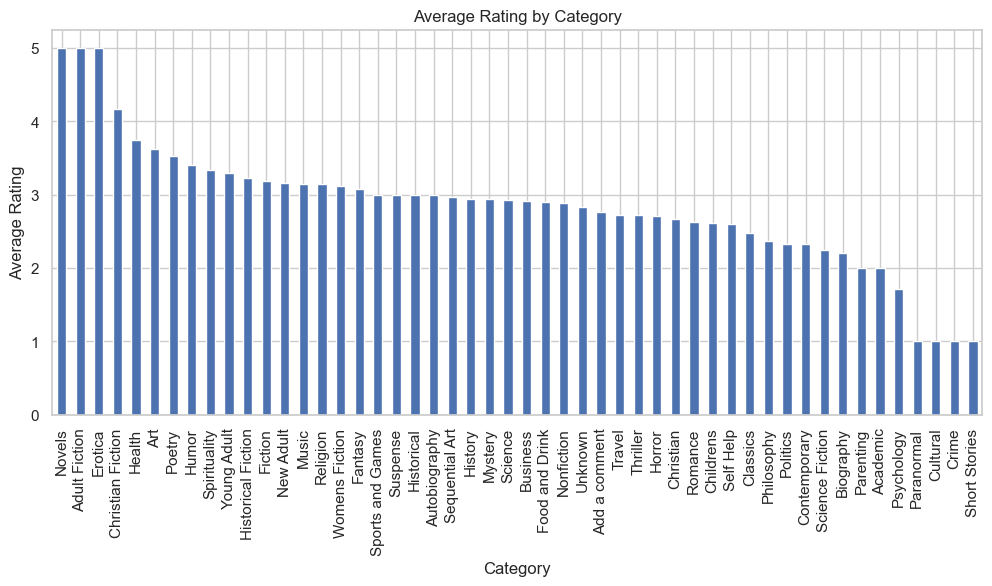

In [26]:
category_rating = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)

category_rating.plot(kind="bar", figsize=(12,5))
plt.title("Average Rating by Category")
plt.ylabel("Average Rating")
plt.show()

- Categories like **Erotica, Adult Fiction, and Novels** have the highest average ratings (~5).
- Categories such as **Psychology, Cultural, and Short Stories** have the lowest ratings (~1–2).
- Most categories fall in the **2.5–3.5 range**, indicating generally moderate performance.

Interpretation:
- Book performance varies significantly by category.
- Certain genres consistently perform better, suggesting **strong reader preference for specific categories**.

### Top 10 Categories

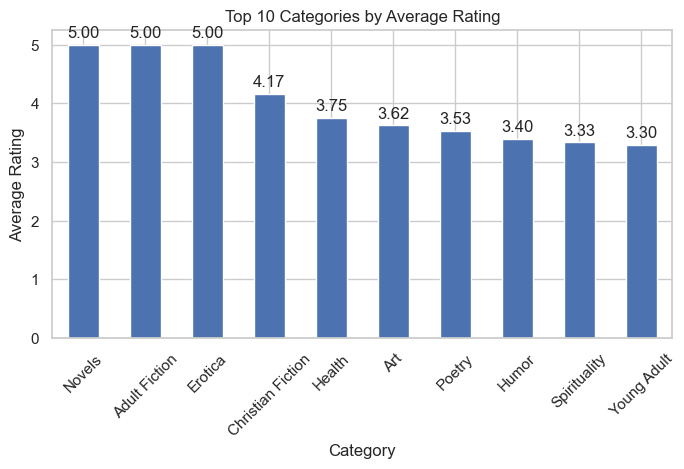

In [27]:
top10 = category_rating.head(10)

ax=top10.plot(kind="bar", figsize=(8,4))

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title("Top 10 Categories by Average Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

- Categories like **Erotica, Adult Fiction, and Novels** have the highest ratings (~5).
- Other top categories maintain ratings above **3.3**, indicating strong performance.

Interpretation:
- Certain genres consistently receive higher ratings, showing clear **reader preference**.

### Bottom 10 Categories

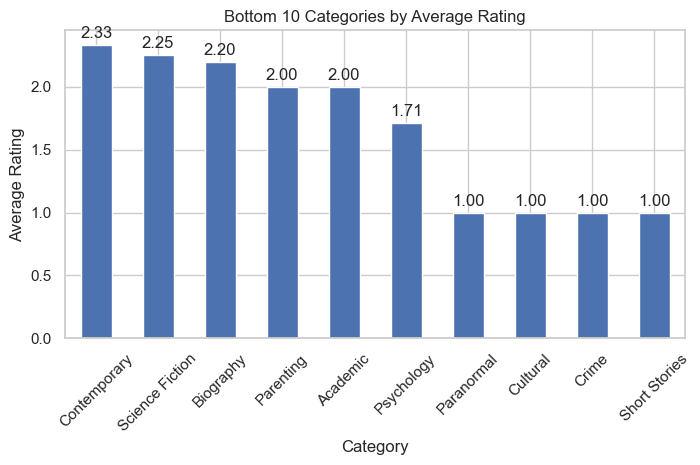

In [28]:
bottom10 = category_rating.tail(10)

ax=bottom10.plot(kind="bar", figsize=(8,4))

ax.bar_label(ax.containers[0], fmt='%.2f', padding=3)

plt.title("Bottom 10 Categories by Average Rating")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

- Categories like **Crime, Cultural, Paranormal, and Short Stories** have the lowest ratings (~1).
- Several categories fall below **2.5**, indicating weak performance.

Interpretation:
- Some genres consistently underperform, suggesting **lower reader satisfaction**.

### Price vs Rating Relationship

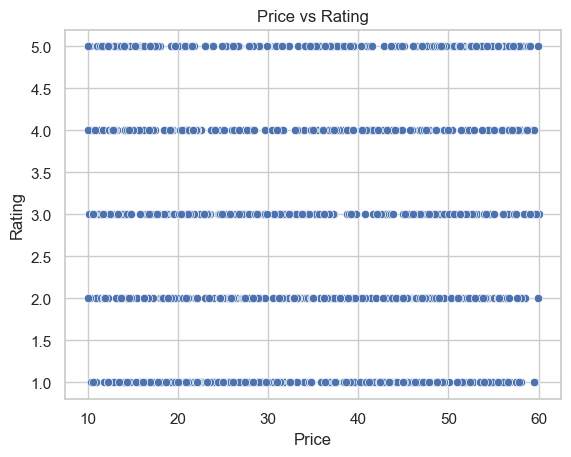

In [29]:
sns.scatterplot(x="Price", y="Rating", data=df)
plt.title("Price vs Rating")
plt.show()

- Ratings are spread evenly across all price ranges.
- No clear upward or downward trend between price and rating.

Interpretation:
- There is **no strong relationship between price and rating**.
- Higher-priced books do not guarantee better ratings.

In [30]:
df[["Price", "Rating"]].corr()

,Price,Rating
Price,1.000000,0.028166
Rating,0.028166,1.000000


### Price Band vs Rating

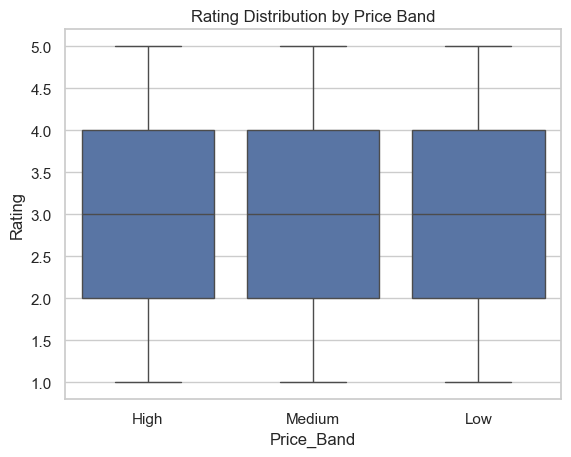

In [31]:
sns.boxplot(x="Price_Band", y="Rating", data=df)
plt.title("Rating Distribution by Price Band")
plt.show()

- All price bands (Low, Medium, High) show **similar rating distributions**.
- Median rating across all groups is around **3**.
- Spread of ratings is nearly identical for each price band.

Interpretation:
- Price range does not significantly influence ratings.
- Both low and high-priced books receive similar levels of customer satisfaction.

### Correlation Heatmap

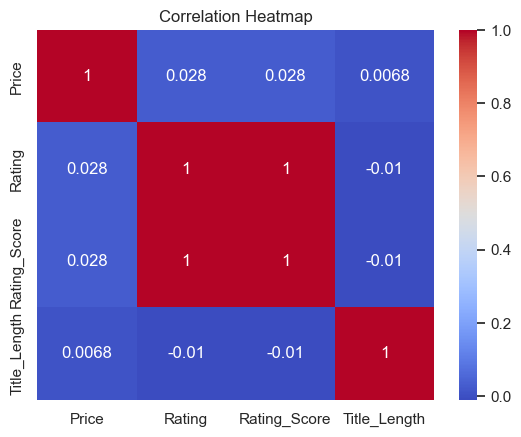

In [32]:
corr = df[["Price", "Rating", "Rating_Score", "Title_Length"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

- Price and Rating show **almost no correlation (~0.03)**.
- Rating and Rating_Score have **perfect correlation (1.0)**, as expected since they are derived.
- Title_Length has **no meaningful relationship** with Price or Rating.

Interpretation:
- Price does not influence customer ratings.
- Title length is not a significant factor affecting ratings.
- Rating_Score does not add new information beyond Rating.

### Outlier Analysis (Price)

We analyze the distribution of prices to detect any outliers that may affect analysis.

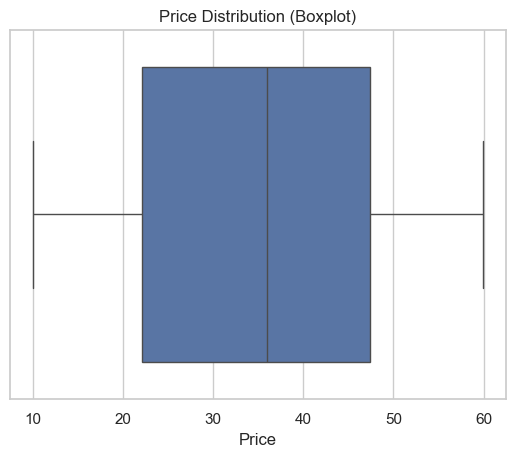

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["Price"])
plt.title("Price Distribution (Boxplot)")
plt.show()

- Price distribution is evenly spread between ~10 and 60.
- No visible outliers (no points outside whiskers).
- Median price is around the mid-range (~35–36).

Interpretation:
- The dataset does not contain extreme price values.
- Pricing is stable and well-distributed, making it reliable for analysis and modeling.

## Key Insights Summary

- Book prices are evenly distributed between 10 and 60, with no dominant price range.
- Average ratings are around 3, indicating overall moderate customer satisfaction.

- Ratings are fairly evenly distributed, with a slight concentration of low-rated books.
- Significant variation exists across categories, with some genres consistently outperforming others.

- Top-performing categories include Erotica, Adult Fiction, and Novels, while categories like Cultural, Paranormal, and Short Stories show low ratings.

- There is no strong relationship between price and rating, confirmed by both scatter plot and boxplot analysis.
- Price bands (Low, Medium, High) show similar rating distributions, indicating price does not impact perceived quality.

- Correlation analysis confirms:
  - No meaningful relationship between price and rating
  - Title length has negligible impact on ratings
  - Rating_Score is redundant as it directly depends on rating

# PHASE 4 : MACHINE LEARNING MODEL 

## Machine Learning Model

In this phase, we build a classification model to predict whether a book will receive a **Good Rating**.

Target Variable:
- Good Rating → 1
- Not Good Rating → 0

We use Logistic Regression and handle class imbalance to improve model performance.

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### Target Variable Creation

We convert rating categories into a binary target variable.

In [35]:
df["Target"] = df["Rating_Category"].apply(lambda x: 1 if x == "Good" else 0)

df["Target"].value_counts()

Target
0    625
1    375
Name: count, dtype: int64

### Feature Selection

We select relevant features for model training:
- Price
- Title Length
- Category (encoded)

In [36]:
df["Category_Code"] = df["Category"].astype("category").cat.codes

X = df[["Price", "Title_Length", "Category_Code"]]
y = df["Target"]

### Train-Test Split

We split the dataset into training and testing sets (80/20 split).

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Model Training

We use Logistic Regression with class balancing to handle imbalanced data.

In [38]:
model = LogisticRegression(class_weight='balanced')

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

### Model Evaluation

We evaluate the model using:
- Accuracy
- Classification Report
- Confusion Matrix

In [39]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.515

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.51      0.56       120
           1       0.42      0.53      0.46        80

    accuracy                           0.52       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.54      0.52      0.52       200


Confusion Matrix:
 [[61 59]
 [38 42]]


### Model Insights

- The model achieved an accuracy of approximately **51–52%**.
- Unlike the initial model, it successfully predicts both classes (Good and Not Good).

Interpretation:
- Class balancing improved the model’s ability to detect high-rated books.
- The confusion matrix shows a more balanced prediction across both classes.
- Recall for the "Good" class improved, indicating better identification of high-rated books.

Conclusion:
- Although overall accuracy is moderate, the model is more reliable and meaningful.
- The results confirm EDA findings that features like price and title length have limited predictive power.
- The dataset lacks strong features for accurate prediction of ratings.

In [40]:
df.head()

,Title,Price,Rating,Product_URL,Category,Price_Band,Rating_Category,Rating_Score,Title_Length,Target,Category_Code
0,A Light in the Attic,51.77,3,http://books.toscrape.com/catalogue/a-light-in...,Poetry,High,Average,0.6,20,0,32
1,Tipping the Velvet,53.74,1,http://books.toscrape.com/catalogue/tipping-th...,Historical Fiction,High,Poor,0.2,18,0,20
2,Soumission,50.10,1,http://books.toscrape.com/catalogue/soumission...,Fiction,High,Poor,0.2,10,0,16
3,Sharp Objects,47.82,4,http://books.toscrape.com/catalogue/sharp-obje...,Mystery,High,Good,0.8,13,1,25
4,Sapiens: A Brief History of Humankind,54.23,5,http://books.toscrape.com/catalogue/sapiens-a-...,History,High,Good,1.0,37,1,21


In [41]:
pd.set_option('display.max_rows', None)
df

,Title,Price,Rating,Product_URL,Category,Price_Band,Rating_Category,Rating_Score,Title_Length,Target,Category_Code
0,A Light in the Attic,51.77,3,http://books.toscrape.com/catalogue/a-light-in...,Poetry,High,Average,0.6,20,0,32
1,Tipping the Velvet,53.74,1,http://books.toscrape.com/catalogue/tipping-th...,Historical Fiction,High,Poor,0.2,18,0,20
2,Soumission,50.10,1,http://books.toscrape.com/catalogue/soumission...,Fiction,High,Poor,0.2,10,0,16
3,Sharp Objects,47.82,4,http://books.toscrape.com/catalogue/sharp-obje...,Mystery,High,Good,0.8,13,1,25
4,Sapiens: A Brief History of Humankind,54.23,5,http://books.toscrape.com/catalogue/sapiens-a-...,History,High,Good,1.0,37,1,21
5,The Requiem Red,22.65,1,http://books.toscrape.com/catalogue/the-requie...,Young Adult,Medium,Poor,0.2,15,0,49
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,http://books.toscrape.com/catalogue/the-dirty-...,Business,Medium,Good,0.8,50,1,6
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,http://books.toscrape.com/catalogue/the-coming...,Unknown,Low,Average,0.6,87,0,47
8,The Boys in the Boat: Nine Americans and Their...,22.60,4,http://books.toscrape.com/catalogue/the-boys-i...,Unknown,Medium,Good,0.8,94,1,47
9,The Black Maria,52.15,1,http://books.toscrape.com/catalogue/the-black-...,Poetry,High,Poor,0.2,15,0,32


In [43]:
dashboard_df = df[[
    "Title",
    "Price",
    "Rating",
    "Category",
    "Price_Band",
    "Rating_Category",
    "Title_Length"
]]

dashboard_df.to_csv("dashboard_books_data.csv", index=False)

print("Dashboard dataset saved successfully!")

Dashboard dataset saved successfully!
